In [1]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from surprise import Dataset, Reader, SVD, accuracy
from surprise.model_selection import train_test_split, cross_validate

print("All libraries imported successfully!")

All libraries imported successfully!


In [2]:
# Loading the Data
# loading the ratings and movies files from the MovieLens 100K dataset
# u.data contains: user_id, movie_id, rating, timestamp
# u.item contains: movie_id, movie_title and other info

ratings = pd.read_csv(r'C:\Users\Administrator\Downloads\ml-100k\u.data', 
                      sep='\t', 
                      names=['user_id', 'movie_id', 'rating', 'timestamp'])

movies = pd.read_csv(r'C:\Users\Administrator\Downloads\ml-100k\u.item',
                     sep='|',
                     encoding='latin-1',
                     names=['movie_id', 'title', 'release_date', 'video_release', 
                            'imdb_url'] + [f'genre_{i}' for i in range(19)])

print("Ratings dataset shape:", ratings.shape)
print("Movies dataset shape:", movies.shape)
print("\nFirst 5 ratings:")
ratings.head()

Ratings dataset shape: (100000, 4)
Movies dataset shape: (1682, 24)

First 5 ratings:


,user_id,movie_id,rating,timestamp
0,196,242,3,881250949
1,186,302,3,891717742
2,22,377,1,878887116
3,244,51,2,880606923
4,166,346,1,886397596


In [3]:
# Data Cleaning & Preprocessing

# Checking for missing values in both datasets
print("Missing values in ratings:")
print(ratings.isnull().sum())

print("\nMissing values in movies:")
print(movies.isnull().sum())

# Checking for duplicates
print("\nDuplicate rows in ratings:", ratings.duplicated().sum())

# Checking rating value range (should be 1-5)
print("\nRating value counts:")
print(ratings['rating'].value_counts().sort_index())

# Droping the timestamp column 
ratings = ratings.drop(columns=['timestamp'])

print("\nCleaned ratings dataset shape:", ratings.shape)
print(ratings.head())

Missing values in ratings:
user_id      0
movie_id     0
rating       0
timestamp    0
dtype: int64

Missing values in movies:
movie_id            0
title               0
release_date        1
video_release    1682
imdb_url            3
genre_0             0
genre_1             0
genre_2             0
genre_3             0
genre_4             0
genre_5             0
genre_6             0
genre_7             0
genre_8             0
genre_9             0
genre_10            0
genre_11            0
genre_12            0
genre_13            0
genre_14            0
genre_15            0
genre_16            0
genre_17            0
genre_18            0
dtype: int64

Duplicate rows in ratings: 0

Rating value counts:
rating
1     6110
2    11370
3    27145
4    34174
5    21201
Name: count, dtype: int64

Cleaned ratings dataset shape: (100000, 3)
   user_id  movie_id  rating
0      196       242       3
1      186       302       3
2       22       377       1
3      244        51       2
4  

In [4]:
# Further cleaning of the movies dataset
# Droping the video_release column as it's entirely empty
movies = movies.drop(columns=['video_release', 'imdb_url'])

# Keeping only the columns we need: movie_id and title
movies_clean = movies[['movie_id', 'title']].copy()

# Fill the one missing release_date 
movies['release_date'] = movies['release_date'].fillna('Unknown')

print("Cleaned movies dataset:")
print(movies_clean.head())
print("\nShape:", movies_clean.shape)

Cleaned movies dataset:
   movie_id              title
0         1   Toy Story (1995)
1         2   GoldenEye (1995)
2         3  Four Rooms (1995)
3         4  Get Shorty (1995)
4         5     Copycat (1995)

Shape: (1682, 2)


C:\Users\Administrator\AppData\Local\Temp\ipykernel_26028\4163072599.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='rating', data=ratings, palette='viridis')


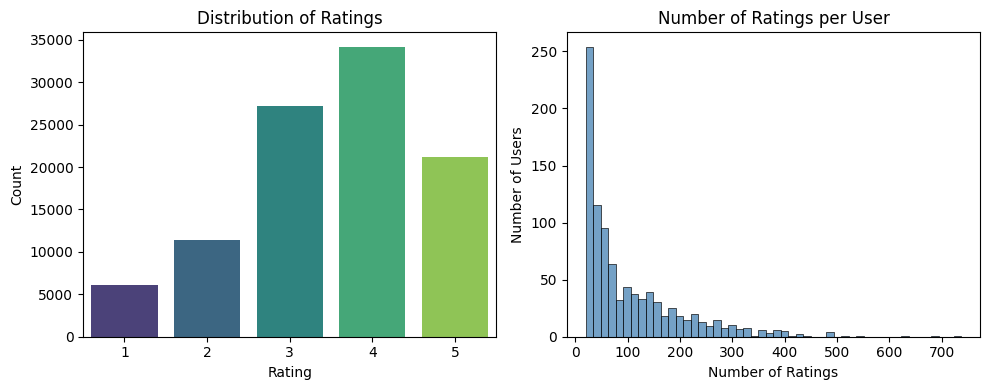

Average rating: 3.53
Most active user rated: 737 movies
Least active user rated: 20 movies


In [5]:
# Exploratory Data Analysis (EDA)

plt.figure(figsize=(10, 4))

# Plot 1: Distribution of Ratings
plt.subplot(1, 2, 1)
sns.countplot(x='rating', data=ratings, palette='viridis')
plt.title('Distribution of Ratings')
plt.xlabel('Rating')
plt.ylabel('Count')

# Plot 2: Number of ratings per user
plt.subplot(1, 2, 2)
ratings_per_user = ratings.groupby('user_id')['rating'].count()
sns.histplot(ratings_per_user, bins=50, color='steelblue')
plt.title('Number of Ratings per User')
plt.xlabel('Number of Ratings')
plt.ylabel('Number of Users')

plt.tight_layout()
plt.show()

# Basic statistics
print("Average rating:", round(ratings['rating'].mean(), 2))
print("Most active user rated:", ratings_per_user.max(), "movies")
print("Least active user rated:", ratings_per_user.min(), "movies")

C:\Users\Administrator\AppData\Local\Temp\ipykernel_26028\2908833196.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='rating_count', y='title', data=top_movies, palette='magma')


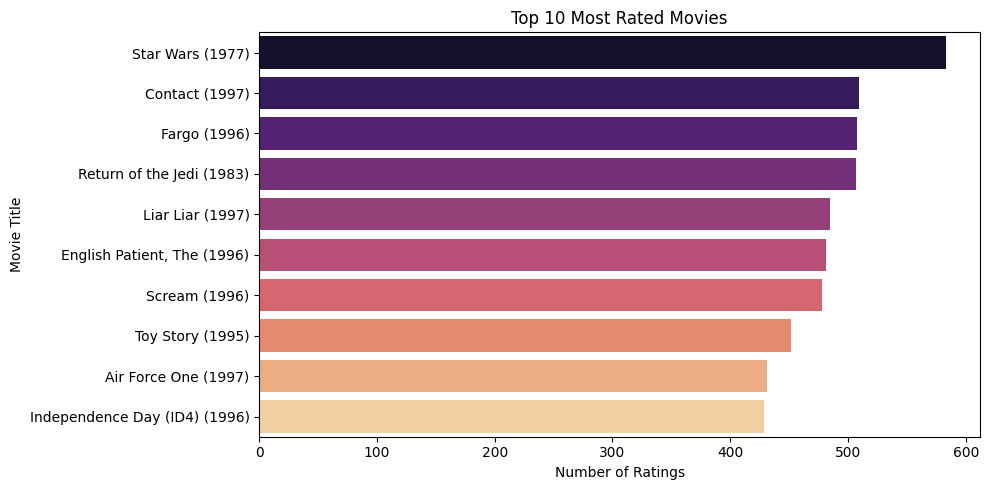

In [6]:
# Top 10 most rated movies
top_movies = ratings.groupby('movie_id')['rating'].count().reset_index()
top_movies.columns = ['movie_id', 'rating_count']
top_movies = top_movies.merge(movies_clean, on='movie_id')
top_movies = top_movies.sort_values('rating_count', ascending=False).head(10)

plt.figure(figsize=(10, 5))
sns.barplot(x='rating_count', y='title', data=top_movies, palette='magma')
plt.title('Top 10 Most Rated Movies')
plt.xlabel('Number of Ratings')
plt.ylabel('Movie Title')
plt.tight_layout()
plt.show()

In [7]:
# Feature Engineering
# defining the rating scale (1-5) using Reader, then loading it into Surprise's Dataset format

from surprise import Reader, Dataset

# Define the rating scale
reader = Reader(rating_scale=(1, 5))

# Load the ratings dataframe into Surprise format
# Surprise needs exactly 3 columns: user_id, movie_id, rating
data = Dataset.load_from_df(ratings[['user_id', 'movie_id', 'rating']], reader)

print("Data loaded into Surprise format successfully!")
print("Number of users:", ratings['user_id'].nunique())
print("Number of movies:", ratings['movie_id'].nunique())
print("Number of ratings:", len(ratings))

Data loaded into Surprise format successfully!
Number of users: 943
Number of movies: 1682
Number of ratings: 100000


In [8]:
# Model Building
# using SVD (Singular Value Decomposition) 

from surprise import SVD
from surprise.model_selection import train_test_split

# Split data: 80% for training, 20% for testing
# Training = the model learns from this data
# Testing = we use this to check how accurate the model is
trainset, testset = train_test_split(data, test_size=0.20, random_state=42)

# Build and train the SVD model
model = SVD(random_state=42)
model.fit(trainset)

print("Model trained successfully!")
print("Training set size:", trainset.n_ratings, "ratings")
print("Test set size:", len(testset), "ratings")

Model trained successfully!
Training set size: 80000 ratings
Test set size: 20000 ratings


In [9]:
# Model Evaluation
# testing the model on the 20,000 ratings it has never seen before
# RMSE (Root Mean Square Error) tells how far off our predictions are

from surprise import accuracy

# Make predictions on the test set
predictions = model.test(testset)

# Calculate RMSE and MAE
rmse = accuracy.rmse(predictions)
mae = accuracy.mae(predictions)

print(f"\nRMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")
print("\nInterpretation:")
print(f"On average our model's rating prediction is {rmse:.2f} stars away from the actual rating")

RMSE: 0.9352
MAE:  0.7375

RMSE: 0.9352
MAE: 0.7375

Interpretation:
On average our model's rating prediction is 0.94 stars away from the actual rating


In [10]:
# Generating Movie Recommendations for a User
# We pick a user and recommend movies they haven't seen yet
# The model predicts what rating they would give each unseen movie
# Then we show the top N movies with the highest predicted ratings

def get_recommendations(user_id, n=10):
    # Get list of all movie IDs
    all_movie_ids = ratings['movie_id'].unique()
    
    # Get movies this user has already rated
    watched = ratings[ratings['user_id'] == user_id]['movie_id'].unique()
    
    # Get movies the user hasn't watched yet
    unwatched = [m for m in all_movie_ids if m not in watched]
    
    # Predict ratings for all unwatched movies
    predictions_list = [model.predict(user_id, movie_id) for movie_id in unwatched]
    
    # Sort by predicted rating (highest first)
    predictions_list.sort(key=lambda x: x.est, reverse=True)
    
    # Get top N recommendations
    top_n = predictions_list[:n]
    
    # Match movie IDs to titles
    recommended = []
    for pred in top_n:
        title = movies_clean[movies_clean['movie_id'] == pred.iid]['title'].values[0]
        recommended.append({'title': title, 'predicted_rating': round(pred.est, 2)})
    
    return pd.DataFrame(recommended)

# Get recommendations for user 1
user_id = 1
print(f"Top 10 Movie Recommendations for User {user_id}:\n")
print(get_recommendations(user_id))

Top 10 Movie Recommendations for User 1:

                                               title  predicted_rating
0  Dr. Strangelove or: How I Learned to Stop Worr...              4.94
1             One Flew Over the Cuckoo's Nest (1975)              4.94
2                                 Rear Window (1954)              4.93
3                            Schindler's List (1993)              4.69
4                              Third Man, The (1949)              4.68
5                       To Kill a Mockingbird (1962)              4.67
6                                  Casablanca (1942)              4.64
7                   Manchurian Candidate, The (1962)              4.55
8                              Close Shave, A (1995)              4.53
9                           L.A. Confidential (1997)              4.52
